In [6]:
import os
import numpy as np
import pandas as pd
import librosa
import joblib
import matplotlib.pyplot as plt
import parselmouth
from parselmouth.praat import call

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.multioutput import MultiOutputClassifier

In [2]:
sample_rate = 16000
audio_files_meta = "metadata.csv"
augmented_meta = "metadata_augmented.csv"
in_dir = "audio_files"
out_dir = "audio_files_augmented"
esc50 = "ESC-50/audio"
esc50_meta = "ESC-50/meta/esc50.csv"
times = 4
audio_files_meta = "metadata.csv"

In [7]:
full_df = pd.read_csv("metadata_augmented.csv")
full_df['original_stem'] = full_df['file_name'].apply(lambda x: x.split('__')[0].replace('.wav', ''))

groups = full_df['original_stem'].values

In [ ]:
import os
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from multiprocessing import Pool

from sk.features import extract_features

if __name__ == '__main__':
    
    file_paths = []
    for _, row in full_df.iterrows():
        fname = row["file_name"]
        if not fname.endswith(".wav"):
            fname += ".wav"
            
        if row["augmentation"] == "original":
            path = os.path.join(in_dir, fname)
        else:
            path = os.path.join(out_dir, fname)
            
        file_paths.append(path)

    start = time.time()
    results = []
    completed = 0

    # 2. Run the pool inside the protected block
    with Pool(processes=6) as pool:
        for features in pool.imap(extract_features, file_paths):
            results.append(features)
            completed += 1
            if completed % 30 == 0:
                elapsed = time.time() - start
                print(f"[{completed}/{len(file_paths)}] {elapsed:.1f}s — {elapsed/completed:.2f}s/file")

    X = np.array(results)
    print(f"Done — {time.time()-start:.1f}s total, shape: {X.shape}")

    # Labels
    y_emotion_raw   = np.array(full_df["emotion"].tolist())    
    y_intensity_raw = np.array(full_df["intensity"].tolist())  
    y_gender_raw    = np.array(full_df["gender"].tolist())     

    emotion_encoder = LabelEncoder()
    intensity_encoder = LabelEncoder()
    gender_encoder = LabelEncoder()

    y_emotion = emotion_encoder.fit_transform(y_emotion_raw)
    y_intensity = intensity_encoder.fit_transform(y_intensity_raw)
    y_gender = gender_encoder.fit_transform(y_gender_raw)

    y = np.column_stack([y_emotion, y_intensity, y_gender])

    
    os.makedirs("models", exist_ok=True)
    np.save("models/X_features.npy", X)
    np.save("models/y_labels.npy", y)
    
    print("Features and labels saved successfully.")

[30/3360] 6.1s — 0.20s/file
[60/3360] 8.2s — 0.14s/file
[90/3360] 10.8s — 0.12s/file
[120/3360] 13.5s — 0.11s/file
[150/3360] 16.3s — 0.11s/file
[180/3360] 18.5s — 0.10s/file
[210/3360] 20.9s — 0.10s/file
[240/3360] 23.3s — 0.10s/file
[270/3360] 25.1s — 0.09s/file
[300/3360] 27.4s — 0.09s/file
[330/3360] 29.4s — 0.09s/file
[360/3360] 31.6s — 0.09s/file
[390/3360] 33.7s — 0.09s/file
[420/3360] 36.0s — 0.09s/file
[450/3360] 38.0s — 0.08s/file
[480/3360] 40.3s — 0.08s/file
[510/3360] 42.4s — 0.08s/file
[540/3360] 44.7s — 0.08s/file
[570/3360] 47.3s — 0.08s/file
[600/3360] 50.0s — 0.08s/file
[630/3360] 52.0s — 0.08s/file
[660/3360] 54.5s — 0.08s/file
[690/3360] 55.4s — 0.08s/file
[720/3360] 55.9s — 0.08s/file
[750/3360] 56.5s — 0.08s/file
[780/3360] 57.0s — 0.07s/file
[810/3360] 57.5s — 0.07s/file
[840/3360] 58.1s — 0.07s/file
[870/3360] 58.4s — 0.07s/file
[900/3360] 58.9s — 0.07s/file
[930/3360] 59.5s — 0.06s/file
[960/3360] 59.9s — 0.06s/file
[990/3360] 60.5s — 0.06s/file
[1020/3360] 61.

In [10]:
joblib.dump(emotion_encoder, os.path.join("models", "svm_emotion_encoder_improv.pkl"))
joblib.dump(intensity_encoder, os.path.join("models", "svm_intensity_encoder_improv.pkl"))
joblib.dump(gender_encoder, os.path.join("models", "svm_gender_encoder_improv.pkl"))

['models/svm_gender_encoder_improv.pkl']

Train size: 2685 | Test size: 675
Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best params: {'estimator__estimator__C': 10, 'estimator__estimator__gamma': 0.01, 'estimator__estimator__kernel': 'rbf'}

EMOTION CLASSIFICATION
              precision    recall  f1-score   support

       angry       0.51      0.50      0.50       105
        calm       0.73      0.67      0.70       140
     disgust       0.40      0.65      0.50        65
     fearful       0.40      0.54      0.46        70
       happy       0.41      0.31      0.35        95
         sad       0.38      0.31      0.34        90
   surprised       0.54      0.51      0.53       110

    accuracy                           0.50       675
   macro avg       0.48      0.50      0.48       675
weighted avg       0.51      0.50      0.50       675


INTENSITY CLASSIFICATION
              precision    recall  f1-score   support

      normal       0.62      0.77      0.69       300
      strong       0.77     

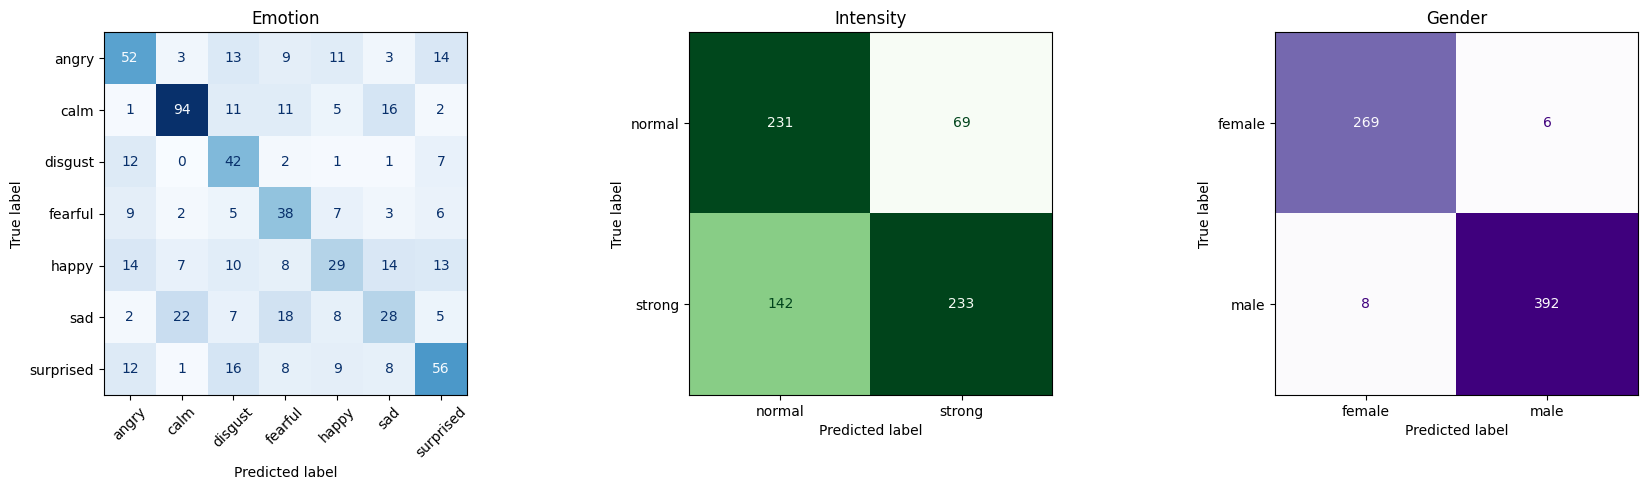

In [ ]:
X = np.load("models/X_features.npy")
y = np.load("models/y_labels.npy")

groups = np.asarray(groups)
if len(groups) != len(X):
    groups = groups[:len(X)]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# gss.split yields indices for train and test
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# We also need to keep the training groups for the GridSearch later
groups_train = groups[train_idx]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

param_grid = {
    "estimator__estimator__C": [0.1, 1, 10],
    "estimator__estimator__gamma": ["scale", 0.001, 0.01],
    "estimator__estimator__kernel": ["rbf"],
}

base_svm = MultiOutputClassifier(
    SVC(class_weight="balanced", probability=True)
 )

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("estimator", base_svm),
])

gkf = GroupKFold(n_splits=5)

multi_svm = GridSearchCV(
    pipe,  # Using the scaler pipeline
    param_grid,
    cv=gkf,
    n_jobs=-1,
    verbose=1,
)

# IMPORTANT: pass groups into fit for GroupKFold
multi_svm.fit(X_train, y_train, groups=groups_train)

print(f"\nBest params: {multi_svm.best_params_}")

joblib.dump(multi_svm, os.path.join("models", "svm_multi_improv.pkl"))

y_pred = multi_svm.predict(X_test)

y_emotion_pred = y_pred[:, 0]
y_intensity_pred = y_pred[:, 1]
y_gender_pred = y_pred[:, 2]

y_emotion_test = y_test[:, 0]
y_intensity_test = y_test[:, 1]
y_gender_test = y_test[:, 2]

print("\n" + "=" * 60)
print("EMOTION CLASSIFICATION")
print("=" * 60)
print(classification_report(y_emotion_test, y_emotion_pred, target_names=emotion_encoder.classes_))

print("\n" + "=" * 60)
print("INTENSITY CLASSIFICATION")
print("=" * 60)
print(classification_report(y_intensity_test, y_intensity_pred, target_names=intensity_encoder.classes_))

print("\n" + "=" * 60)
print("GENDER CLASSIFICATION")
print("=" * 60)
print(classification_report(y_gender_test, y_gender_pred, target_names=gender_encoder.classes_))

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_emotion = confusion_matrix(y_emotion_test, y_emotion_pred)
ConfusionMatrixDisplay(cm_emotion, display_labels=emotion_encoder.classes_).plot(
    ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45
)
axes[0].set_title("Emotion")

cm_intensity = confusion_matrix(y_intensity_test, y_intensity_pred)
ConfusionMatrixDisplay(cm_intensity, display_labels=intensity_encoder.classes_).plot(
    ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title("Intensity")

cm_gender = confusion_matrix(y_gender_test, y_gender_pred)
ConfusionMatrixDisplay(cm_gender, display_labels=gender_encoder.classes_).plot(
    ax=axes[2], cmap="Purples", colorbar=False
)
axes[2].set_title("Gender")

plt.tight_layout()
plt.show()

In [10]:
emotion_encoder = joblib.load(os.path.join("models","svm_emotion_encoder_improv.pkl"))
intensity_encoder = joblib.load(os.path.join("models","svm_intensity_encoder_improv.pkl"))
gender_encoder = joblib.load(os.path.join("models","svm_gender_encoder_improv.pkl"))

multi_svm = joblib.load(os.path.join("models","svm_multi_improv.pkl"))

FileNotFoundError: [Errno 2] No such file or directory: 'models/svm_emotion_encoder_improv.pkl'

In [9]:
from features import extract_features
def extract_features_chunked(file_path, max_duration=4.0):
    y, _ = librosa.load(file_path, sr=sample_rate, mono=True)

    duration = len(y) / sample_rate

    if duration <= max_duration:
        # Short clip — extract directly
        return extract_features(file_path)
    else:
        # Long clip — split into chunks and take the most "energetic" one
        chunk_size = int(max_duration * sample_rate)
        chunks = [y[i:i+chunk_size] for i in range(0, len(y)-chunk_size, chunk_size)]

        # Pick the chunk with highest RMS (most active speech)
        rms_per_chunk = [librosa.feature.rms(y=c).mean() for c in chunks]
        best_chunk = chunks[np.argmax(rms_per_chunk)]

        # Save temp and extract
        import soundfile as sf
        tmp_path = "/tmp/chunk_tmp.wav"
        sf.write(tmp_path, best_chunk, sample_rate)
        return extract_features(tmp_path)

In [ ]:
import datetime
import os
import numpy as np

with open(f"test_logs/svm_improv_{datetime.datetime.now()}.log","w") as log:
    out = ""
    for (dirp, _, files) in os.walk("sk_test_audios"):
        files.sort()
        for f in files:
            out += f"\nFile: {f}\n"
            feature = extract_features_chunked(os.path.join(dirp,f))
            print(f"{f}: min={feature.min():.2f}, max={feature.max():.2f}, nan={np.isnan(feature).sum()}")
            predictions = multi_svm.predict([feature])[0]

            predicted_emotion = emotion_encoder.inverse_transform([predictions[0]])[0]
            predicted_intensity = intensity_encoder.inverse_transform([predictions[1]])[0]
            predicted_gender = gender_encoder.inverse_transform([predictions[2]])[0]

            out += f"\nPredicted Emotion: {predicted_emotion}\n"
            out += f"Predicted Intensity: {predicted_intensity}\n"
            out += f"Predicted Gender: {predicted_gender}\n"

    log.write(out)

audio1.wav: min=-79.90, max=222.16, nan=0
audio2.wav: min=-79.89, max=219.35, nan=0
audio3.wav: min=-80.00, max=222.16, nan=0
audio4.wav: min=-80.00, max=222.16, nan=0
audio5.wav: min=-80.00, max=181.50, nan=0


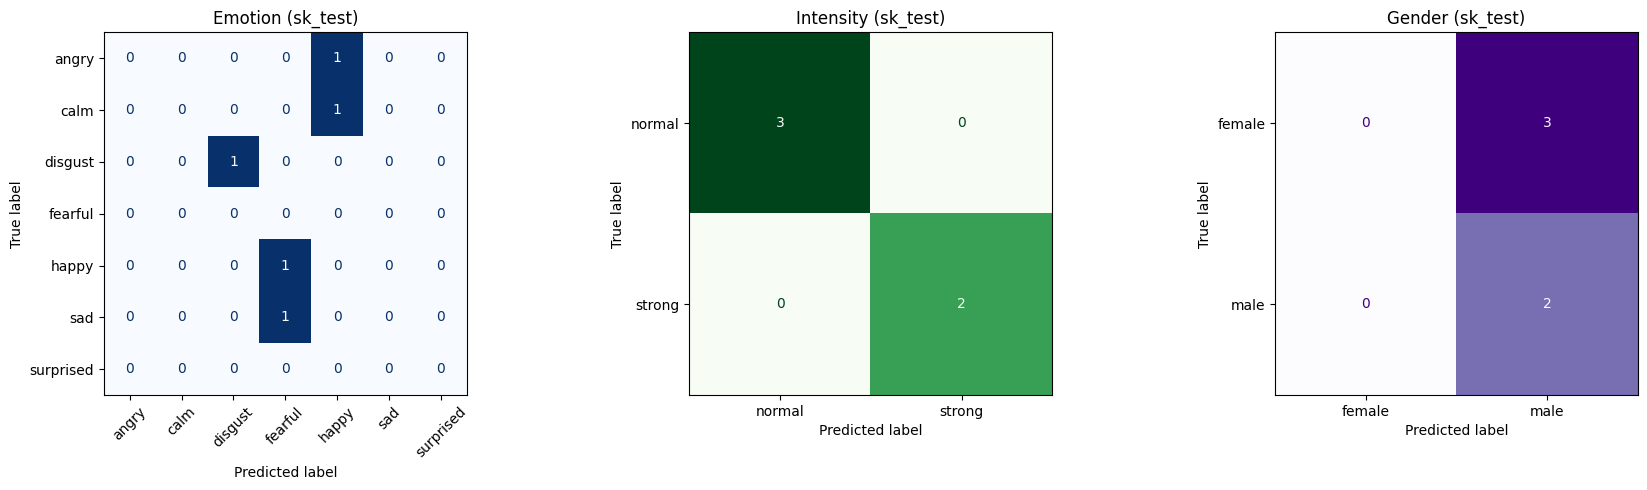


Emotion
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00         1
        calm       0.00      0.00      0.00         1
     disgust       1.00      1.00      1.00         1
     fearful       0.00      0.00      0.00         0
       happy       0.00      0.00      0.00         1
         sad       0.00      0.00      0.00         1
   surprised       0.00      0.00      0.00         0

    accuracy                           0.20         5
   macro avg       0.14      0.14      0.14         5
weighted avg       0.20      0.20      0.20         5


Intensity
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00         3
      strong       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


Gender
              precision    recall  f1-score   su

In [ ]:
sk_meta = pd.read_csv("sk_test_metadata.csv")

true_emotions, true_intensities, true_genders = [], [], []
pred_emotions, pred_intensities, pred_genders = [], [], []

for _, row in sk_meta.iterrows():
    file_path = os.path.join("sk_test_audios", f"audio{row['AudioID']}.wav")
    feature = extract_features(file_path)
    preds = multi_svm.predict([feature])[0]

    true_emotions.append(row["Emotion"].lower())
    true_intensities.append(row["Intensity"].lower())
    true_genders.append(row["Gender"].lower())

    pred_emotions.append(emotion_encoder.inverse_transform([preds[0]])[0])
    pred_intensities.append(intensity_encoder.inverse_transform([preds[1]])[0])
    pred_genders.append(gender_encoder.inverse_transform([preds[2]])[0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_e = confusion_matrix(true_emotions, pred_emotions, labels=emotion_encoder.classes_)
ConfusionMatrixDisplay(cm_e, display_labels=emotion_encoder.classes_).plot(
    ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45
)
axes[0].set_title("Emotion (sk_test)")

cm_i = confusion_matrix(true_intensities, pred_intensities, labels=intensity_encoder.classes_)
ConfusionMatrixDisplay(cm_i, display_labels=intensity_encoder.classes_).plot(
    ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title("Intensity (sk_test)")

cm_g = confusion_matrix(true_genders, pred_genders, labels=gender_encoder.classes_)
ConfusionMatrixDisplay(cm_g, display_labels=gender_encoder.classes_).plot(
    ax=axes[2], cmap="Purples", colorbar=False
)
axes[2].set_title("Gender (sk_test)")

plt.tight_layout()
plt.show()

print("\nEmotion")
print(classification_report(true_emotions, pred_emotions,
                             labels=emotion_encoder.classes_,
                             target_names=emotion_encoder.classes_,
                             zero_division=0))
print("\nIntensity")
print(classification_report(true_intensities, pred_intensities,
                             labels=intensity_encoder.classes_,
                             target_names=intensity_encoder.classes_,
                             zero_division=0))
print("\nGender")
print(classification_report(true_genders, pred_genders,
                             labels=gender_encoder.classes_,
                             target_names=gender_encoder.classes_,
                             zero_division=0))

In [ ]:
for (dirp, _, files) in os.walk("test_audios"):
    files.sort()
    for f in files:
        feature = extract_features_chunked(os.path.join(dirp, f))
        print(f"{f}: min={feature.min():.2f}, max={feature.max():.2f}, nan={np.isnan(feature).sum()}")

In [17]:
import inspect
print(inspect.getsource(extract_features))
print("---")
print(inspect.getsource(extract_features_chunked))

def extract_features(file_path):
    y, _ = librosa.load(file_path, sr=sample_rate, mono=True)

    mfcc = librosa.feature.mfcc(y=y, sr=sample_rate, n_mfcc=13)
    delta_mfcc = librosa.feature.delta(mfcc)
    delta_mfcc_features = delta_mfcc.mean(axis=1)

    chroma = librosa.feature.chroma_stft(
        S=np.abs(librosa.stft(y)), sr=sample_rate
    )
    chroma_features = chroma.mean(axis=1)

    rms = librosa.feature.rms(y=y)
    rms_features = np.array([rms.mean(), rms.std()])

    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sample_rate)
    centroid_normalized = spectral_centroid / (sample_rate / 2)
    centroid_features = np.array([centroid_normalized.mean(), centroid_normalized.std()])

    f0 = librosa.yin(y, fmin=80, fmax=300)
    f0_clean = f0[f0 > 0]
    if len(f0_clean) > 0:
        f0_features = np.array([
            f0_clean.mean(),
            f0_clean.std(),
            f0_clean.max() - f0_clean.min()
        ])
    else:
        f0_features = np.zeros

In [ ]:
y, _ = librosa.load("sk_test_audios/audio1.wav", sr=sample_rate, mono=True)

# Check F0
f0 = librosa.yin(y, fmin=80, fmax=300)
f0_clean = f0[f0 > 0]
print(f"F0: min={f0_clean.min():.2f}, max={f0_clean.max():.2f}")

# Check HNR raw values
snd = parselmouth.Sound("sk_test_audios/audio1.wav")
harmonicity = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
print(f"HNR raw: min={harmonicity.values.min():.2f}, max={harmonicity.values.max():.2f}")
hnr_filtered = harmonicity.values[harmonicity.values > -199]
print(f"HNR filtered: min={hnr_filtered.min():.2f}, max={hnr_filtered.max():.2f}")

# Check MFCC
mfcc = librosa.feature.mfcc(y=y, sr=sample_rate, n_mfcc=13)
print(f"MFCC: min={mfcc.min():.2f}, max={mfcc.max():.2f}")

# Check Spectral Centroid
centroid = librosa.feature.spectral_centroid(y=y, sr=sample_rate)
print(f"Centroid: min={centroid.min():.2f}, max={centroid.max():.2f}")

print(f"X range: min={X.min():.2f}, max={X.max():.2f}")
print(f"X shape: {X.shape}")

F0: min=79.89, max=302.05
HNR raw: min=-200.00, max=19.55
HNR filtered: min=-5.37, max=19.55
MFCC: min=-356.56, max=120.44
Centroid: min=1342.75, max=3576.23
X range: min=-77.25, max=244.14
X shape: (720, 113)


NameError: name 'extract_features_chunked' is not defined